In [1]:
# -----------------------------------------------------------
# Installing Kaggle API
# -----------------------------------------------------------
!pip install kaggle -q

In [3]:
# -----------------------------------------------------------
# Creating Kaggle Directory
# -----------------------------------------------------------
import os

os.makedirs("/root/.kaggle", exist_ok=True)

print(" Kaggle directory created")

 Kaggle directory created


In [4]:
# -----------------------------------------------------------
# Downloading Brain Tumor MRI Dataset
# -----------------------------------------------------------
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 219MB/s]



In [5]:
# -----------------------------------------------------------
# Extracting Dataset
# -----------------------------------------------------------
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# STEP 1: IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training set distribution:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images
  TOTAL: 5600

Test set distribution:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images
  TOTAL: 1600


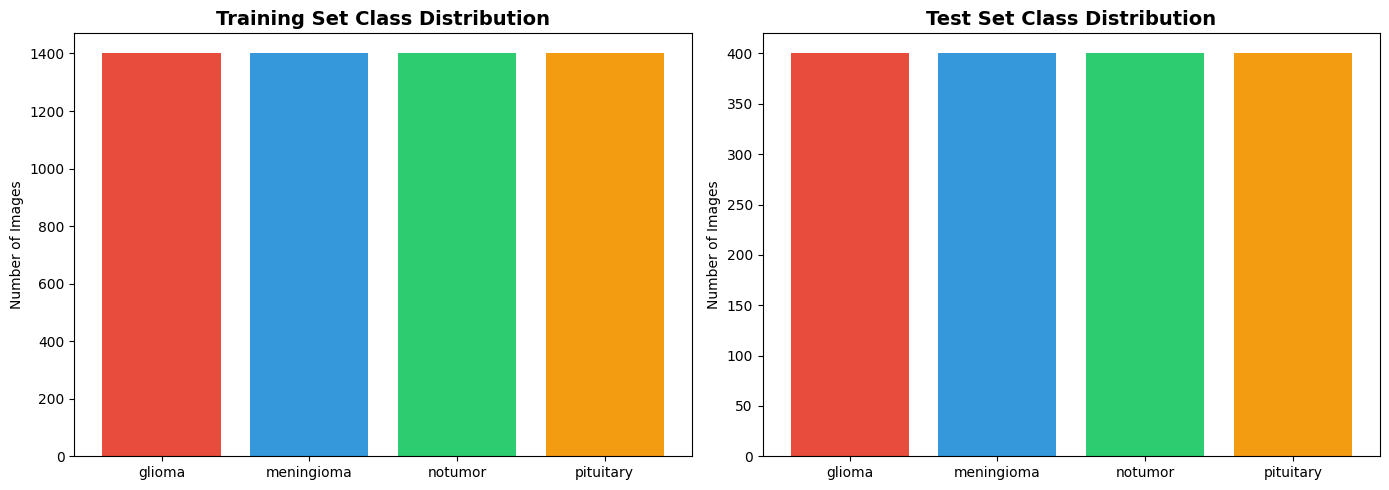

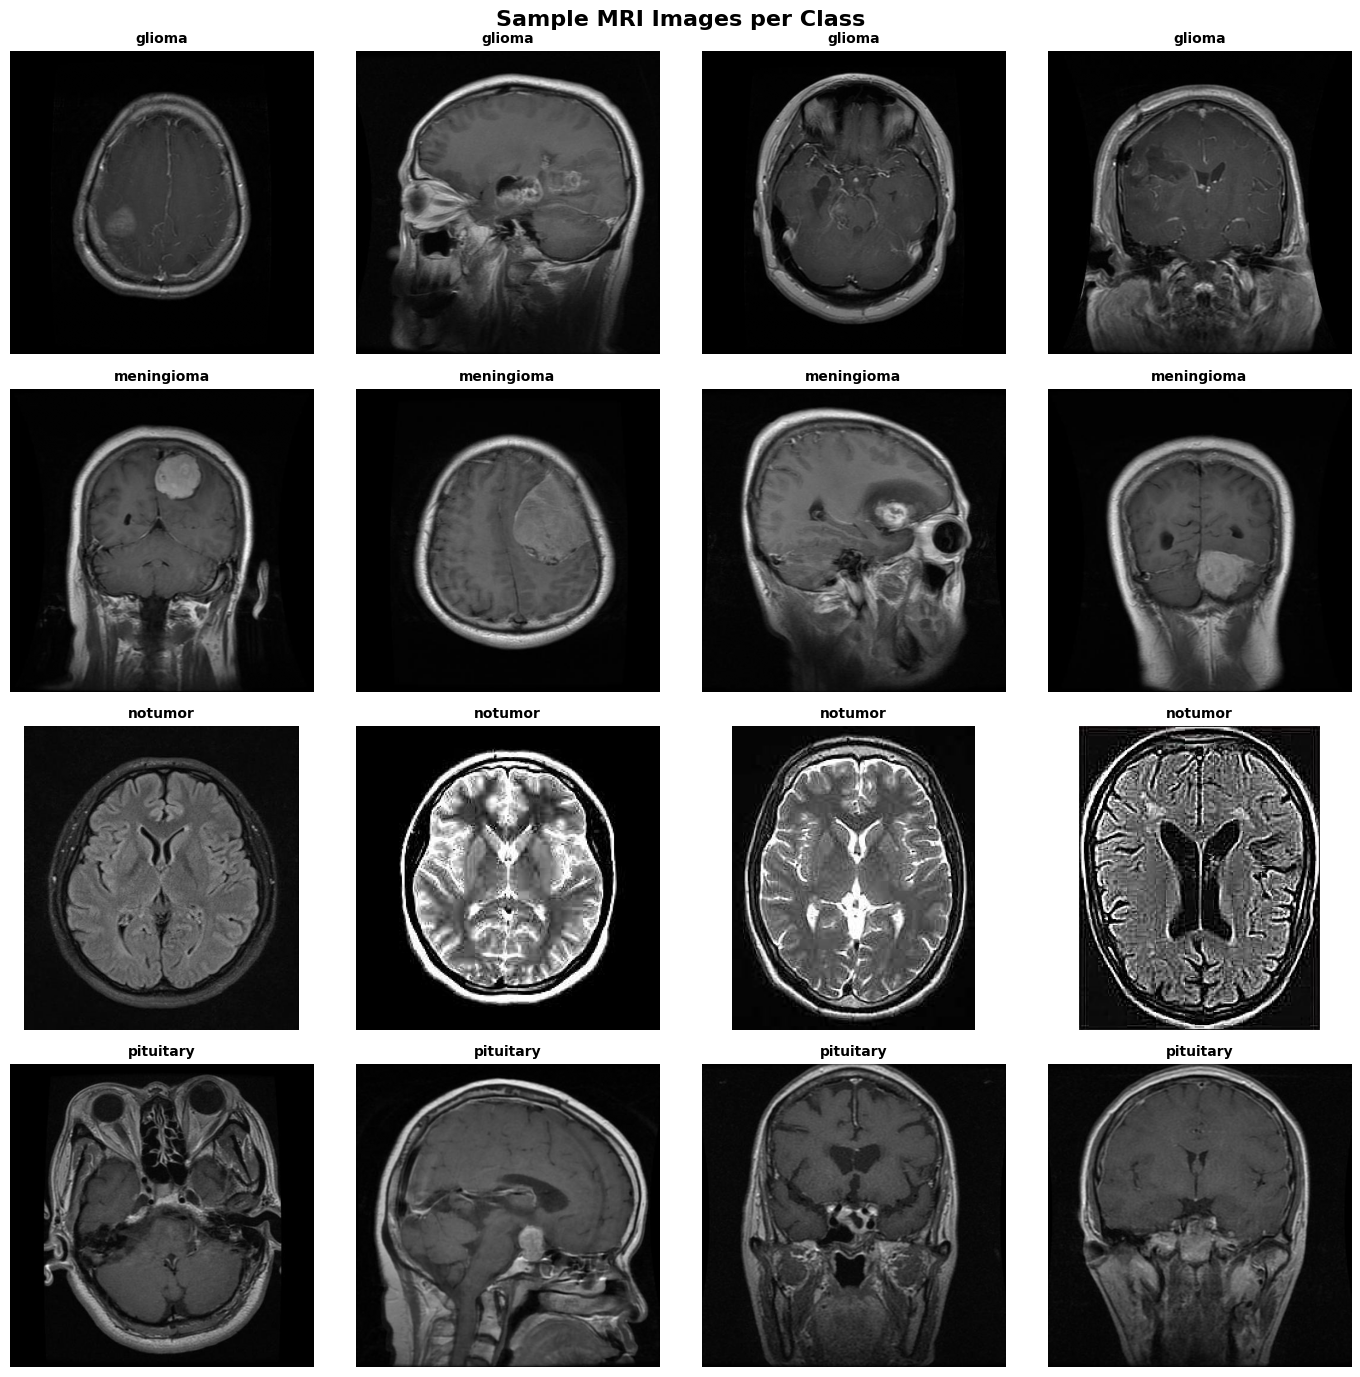

In [6]:
# ============================================================
# STEP 2: DATA UNDERSTANDING & VISUALIZATION
# ============================================================
TRAIN_DIR = '/content/brain_tumor_data/Training'
TEST_DIR  = '/content/brain_tumor_data/Testing'

classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)

# Count images per class
train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(TEST_DIR,  c))) for c in classes}

print("\nTraining set distribution:")
for c, n in train_counts.items():
    print(f"  {c}: {n} images")
print(f"  TOTAL: {sum(train_counts.values())}")

print("\nTest set distribution:")
for c, n in test_counts.items():
    print(f"  {c}: {n} images")
print(f"  TOTAL: {sum(test_counts.values())}")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(train_counts.keys(), train_counts.values(), color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[1].bar(test_counts.keys(), test_counts.values(), color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Images')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample images
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_dir)[:4]
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_dir, img_name)
        img = plt.imread(img_path)
        axes[i][j].imshow(img, cmap='gray' if len(img.shape)==2 else None)
        axes[i][j].set_title(f'{cls}', fontsize=10, fontweight='bold')
        axes[i][j].axis('off')
plt.suptitle('Sample MRI Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

=== Image Size Variability Analysis ===
Width  — min: 173, max: 1168, mean: 450
Height — min: 197, max: 1178, mean: 455

=> Images have variable sizes — all will be resized to (128, 128) during training
=> Resizing ensures uniform input dimensions required by CNN


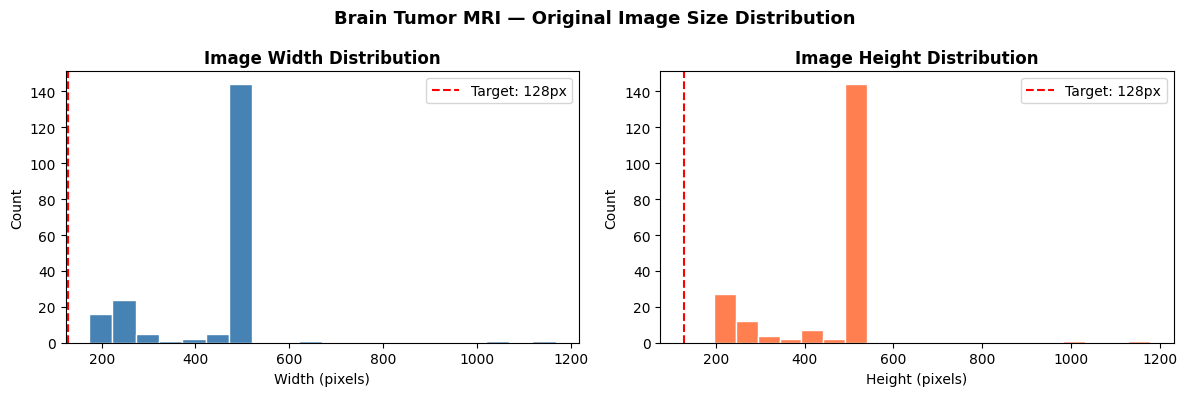

In [7]:
# ============================================================
# IMAGE SIZE VARIABILITY ANALYSIS
# Assignment requirement: discuss preprocessing applied
# ============================================================
IMG_SIZE = (128, 128)
from PIL import Image

print("=== Image Size Variability Analysis ===")
sizes = []
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for img_name in img_files[:50]:
        try:
            with Image.open(os.path.join(cls_path, img_name)) as im:
                sizes.append(im.size)
        except:
            pass

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {int(sum(widths)/len(widths))}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {int(sum(heights)/len(heights))}")
print(f"\n=> Images have variable sizes — all will be resized to {IMG_SIZE} during training")
print(f"=> Resizing ensures uniform input dimensions required by CNN")

# Plot size distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (pixels)'); axes[0].set_ylabel('Count')
axes[0].axvline(IMG_SIZE[0], color='red', linestyle='--', label=f'Target: {IMG_SIZE[0]}px')
axes[0].legend()

axes[1].hist(heights, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Height (pixels)'); axes[1].set_ylabel('Count')
axes[1].axvline(IMG_SIZE[1], color='red', linestyle='--', label=f'Target: {IMG_SIZE[1]}px')
axes[1].legend()

plt.suptitle('Brain Tumor MRI — Original Image Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training samples: 4480
Validation samples: 1120
Test samples: 1600


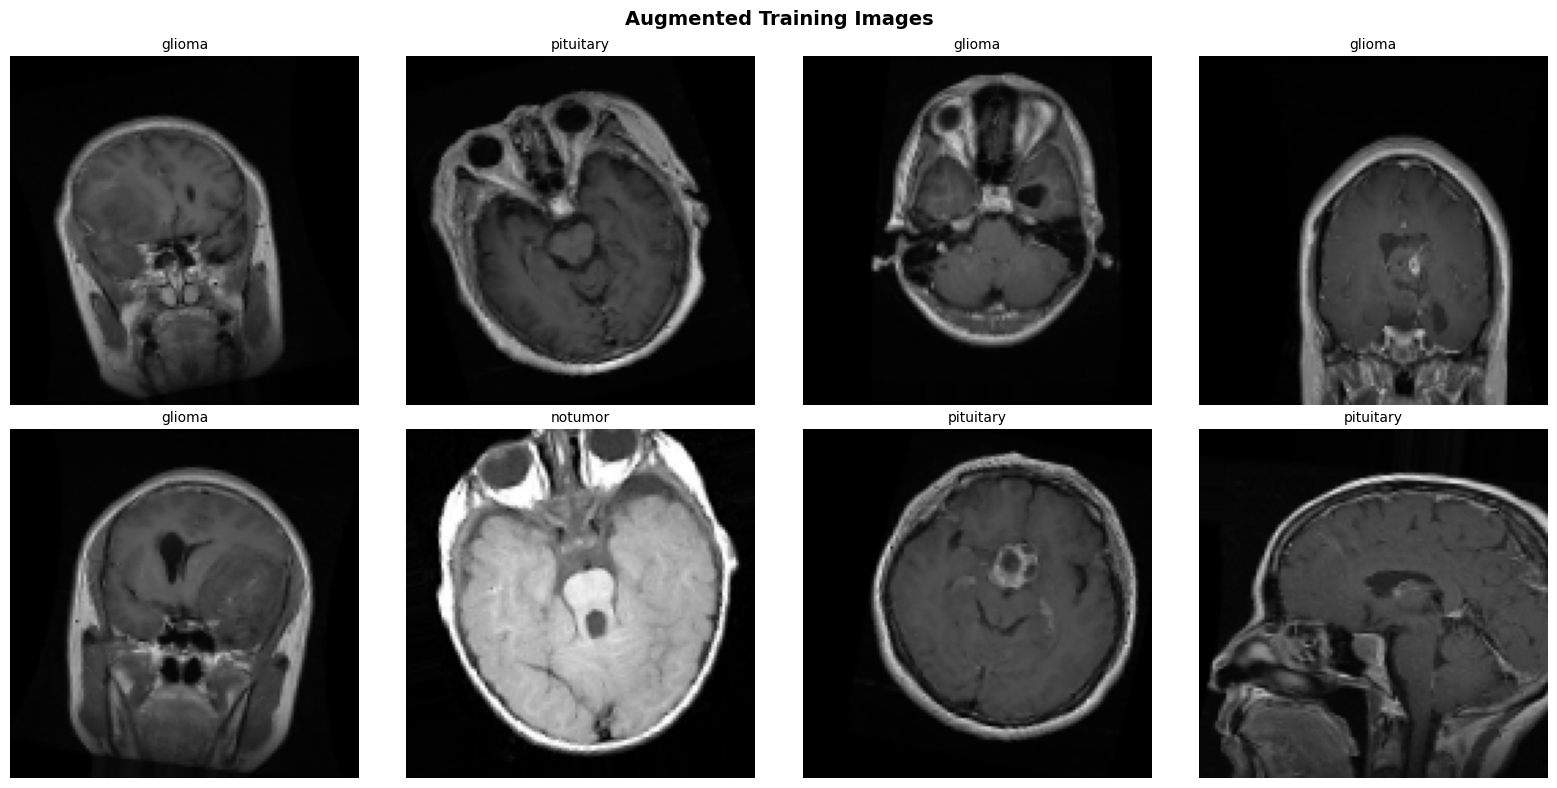

In [8]:
# ============================================================
# STEP 3: DATA GENERATORS WITH AUGMENTATION
# ============================================================
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

# Test/Val generator - only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(classes)
print(f"\nClasses: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

# Visualize augmented images
sample_batch = next(train_generator)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[0][i])
    label_idx = np.argmax(sample_batch[1][i])
    ax.set_title(classes[label_idx], fontsize=10)
    ax.axis('off')
plt.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# HELPER: Plot training curves
# ============================================================
def plot_history(history, model_name, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss',     color='#e74c3c', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='#3498db', linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Loss Curve', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#2ecc71', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#f39c12', linewidth=2, linestyle='--')
    axes[1].set_title(f'{model_name} — Accuracy Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# HELPER: Evaluate model
# ============================================================
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print('='*50)
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return y_pred, y_true


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)


Training Baseline CNN...
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.5723 - loss: 0.9289 - val_accuracy: 0.6750 - val_loss: 0.7319 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 223ms/step - accuracy: 0.7237 - loss: 0.6743 - val_accuracy: 0.7482 - val_loss: 0.6067 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 221ms/step - accuracy: 0.7634 - loss: 0.5645 - val_accuracy: 0.7884 - val_loss: 0.5237 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 242ms/step - accuracy: 0.8011 - loss: 0.5107 - val_accuracy: 0.7884 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 229ms/step - accuracy: 0.8018 - loss: 0.4950 - val_accuracy: 0.8107 - val_loss: 0.4816 - learning_rate: 0.0010
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 228ms/step - accuracy: 0.8272 - loss: 0.4377 - val_accuracy: 0.7554 - val_loss: 0.5659 - learning_rate: 0.0010
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 

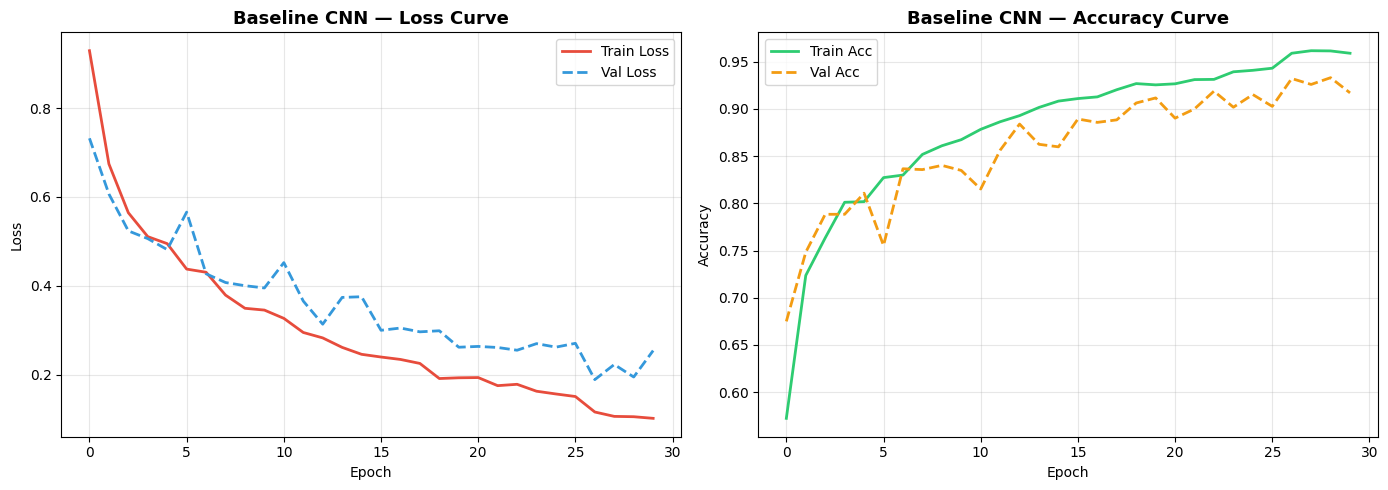


Baseline Test Accuracy: 88.38%
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step

Evaluation: Baseline CNN
              precision    recall  f1-score   support

      glioma       0.96      0.71      0.82       400
  meningioma       0.82      0.84      0.83       400
     notumor       0.82      1.00      0.90       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



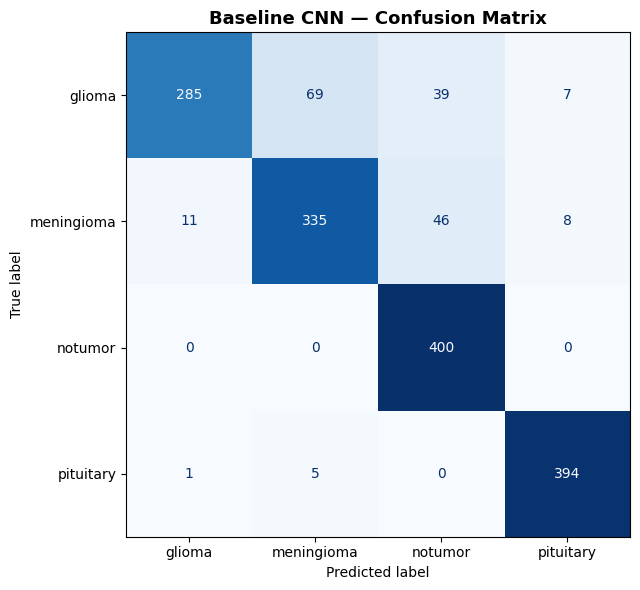

(array([1, 0, 0, ..., 3, 3, 3]), array([0, 0, 0, ..., 3, 3, 3], dtype=int32))

In [ ]:
# ============================================================
# PART A — STEP 1: BASELINE CNN MODEL (3 Conv + 3 FCN)
# ============================================================
def build_baseline_cnn(num_classes):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(128,128,3)),
        layers.MaxPooling2D(2,2),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        # Conv Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

# Callbacks
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("\nTraining Baseline CNN...")
start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_baseline,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)")

plot_history(history_baseline, 'Baseline CNN', 'history_baseline')

# Evaluate baseline
_, baseline_acc = baseline_model.evaluate(test_generator, verbose=0)
print(f"\nBaseline Test Accuracy: {baseline_acc*100:.2f}%")
evaluate_model(baseline_model, test_generator, 'Baseline CNN')


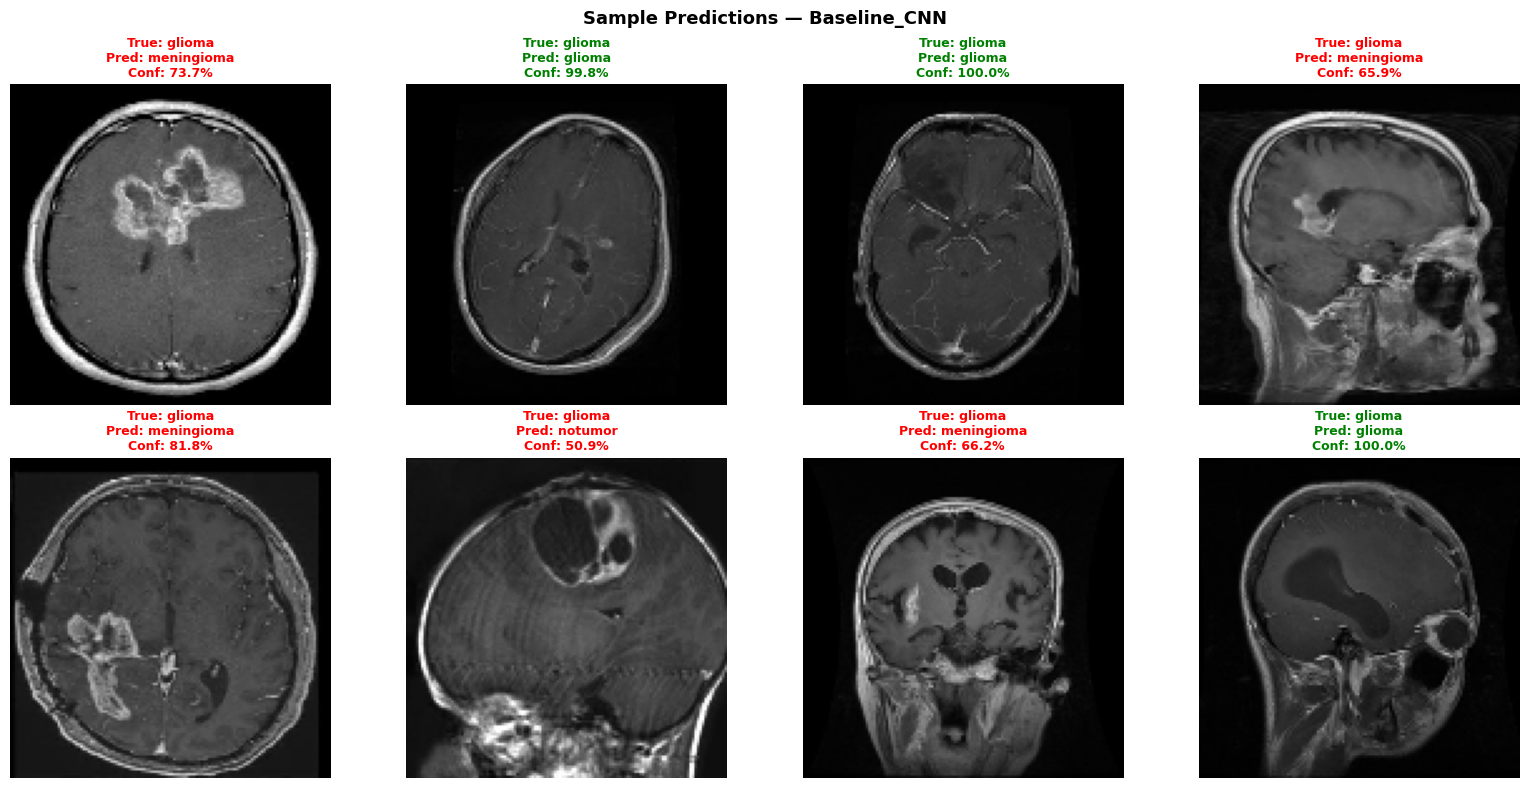

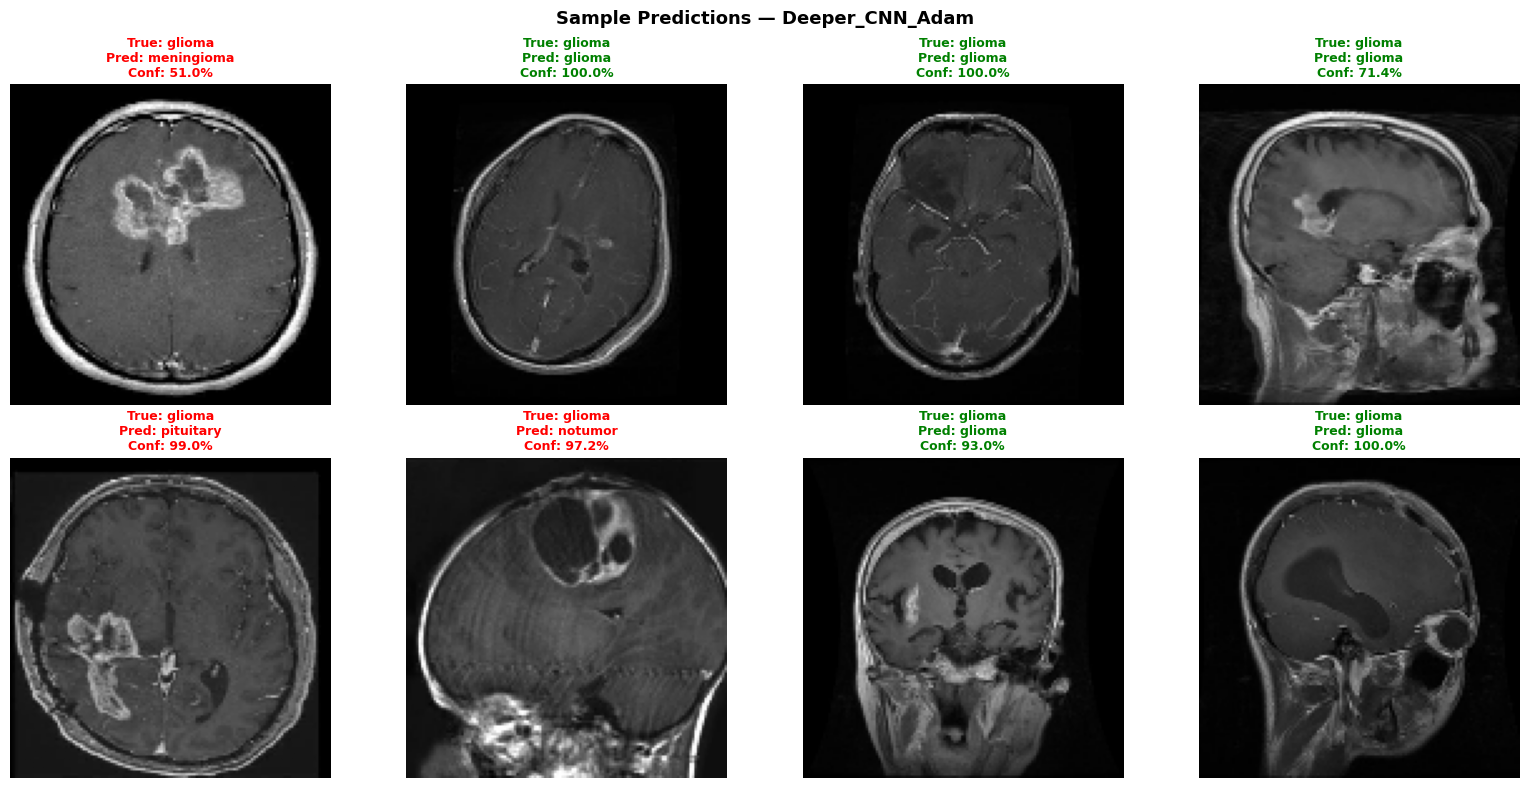

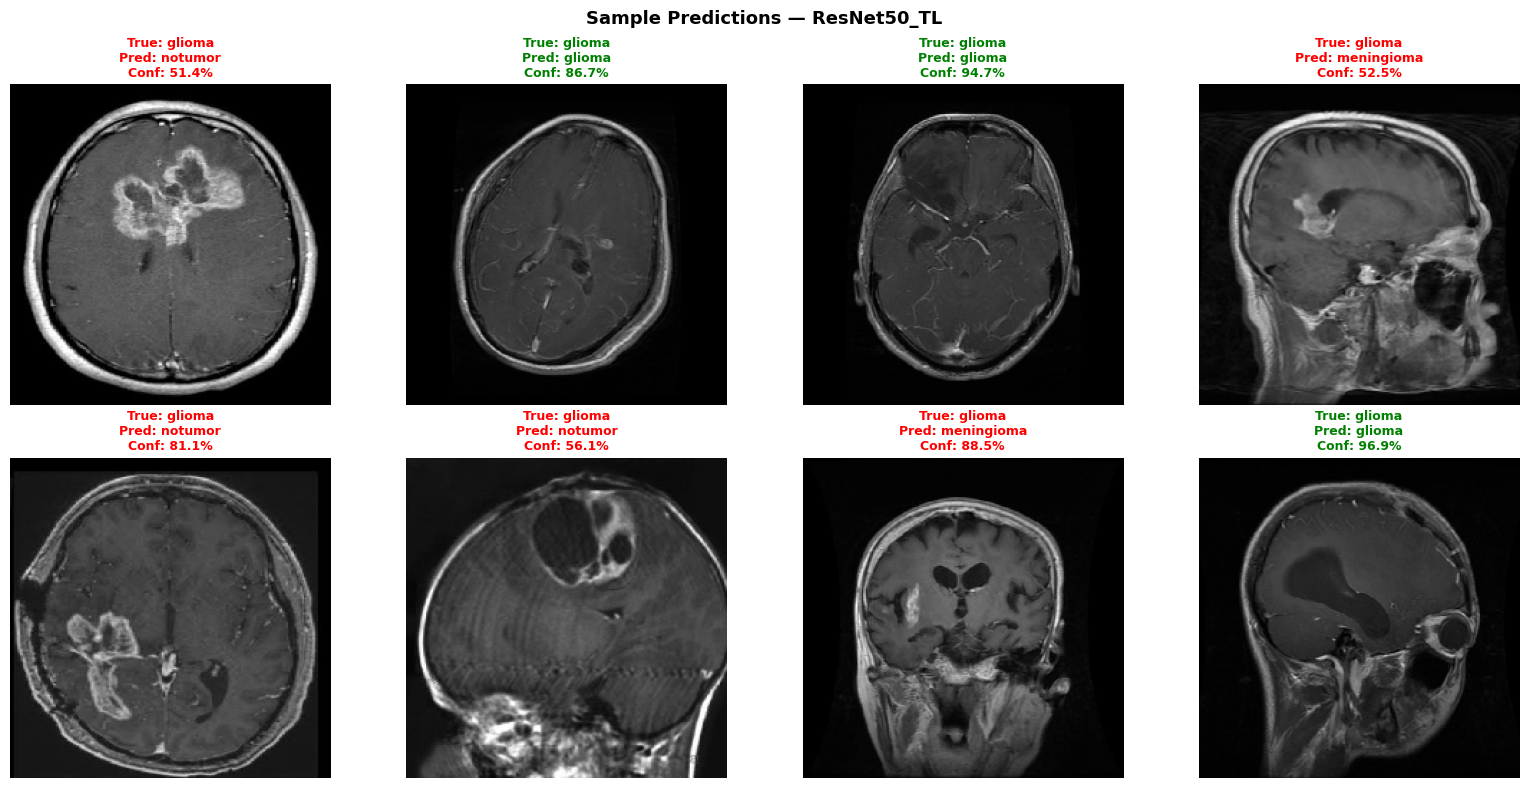

In [ ]:
# Inference on sample test images
def visualize_predictions(model, generator, class_names, model_name):
    generator.reset()
    images, labels = next(generator)
    predictions = model.predict(images, verbose=0)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i])
        true_label = class_names[np.argmax(labels[i])]
        pred_label = class_names[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f'Sample Predictions — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'inference_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(baseline_model, test_generator, classes, 'Baseline_CNN')
visualize_predictions(deeper_model_adam, test_generator, classes, 'Deeper_CNN_Adam')
visualize_predictions(tl_model, tl_test_gen, classes, 'ResNet50_TL')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 9,730,084 (37.12 MB)

 Trainable params: 9,728,100 (37.11 MB)

 Non-trainable params: 1,984 (7.75 KB)


Training Deeper CNN (Adam)...
Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 56s 251ms/step - accuracy: 0.6371 - loss: 0.9254 - val_accuracy: 0.2545 - val_loss: 2.9954 - learning_rate: 0.0010
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 239ms/step - accuracy: 0.7196 - loss: 0.7321 - val_accuracy: 0.2366 - val_loss: 2.5053 - learning_rate: 0.0010
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 272ms/step - accuracy: 0.7719 - loss: 0.5989 - val_accuracy: 0.4607 - val_loss: 1.4412 - learning_rate: 0.0010
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 239ms/step - accuracy: 0.7888 - loss: 0.5449 - val_accuracy: 0.5027 - val_loss: 1.7562 - learning_rate: 0.0010
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.8112 - loss: 0.5063 - val_accuracy: 0.5339 - val_loss: 1.2193 - learning_rate: 0.0010
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.8174 - loss: 0.4794 - val_accuracy: 0.7107 - val_loss: 0.6806 - learning_rate: 0.0010
Epoch 7/40
140/140 ━━━━━━━━━━━━━━━━━━━━

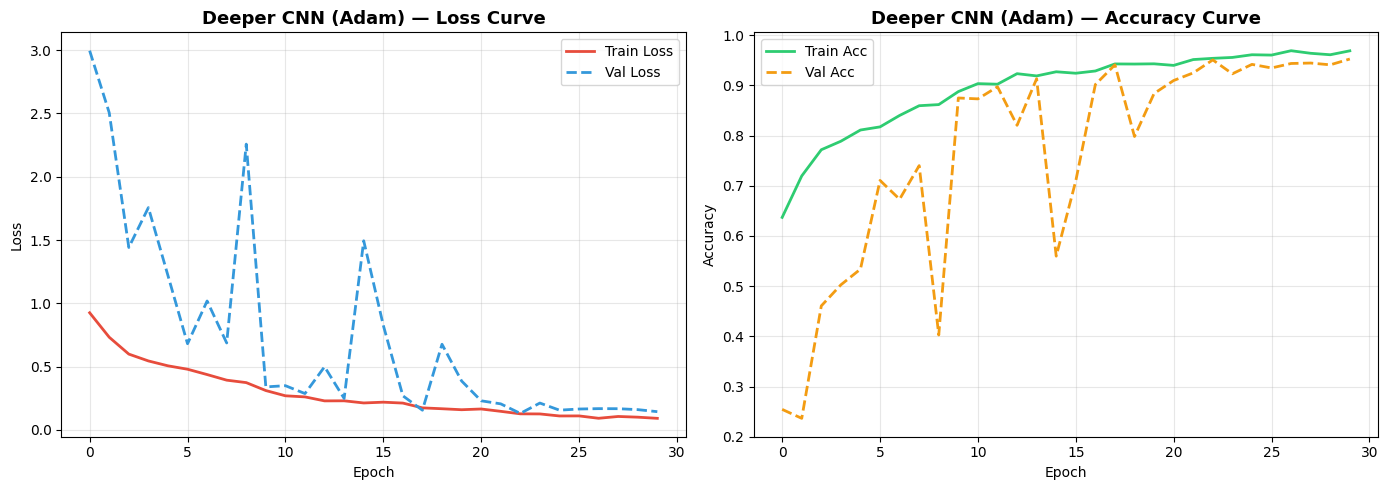

Deeper CNN (Adam) Test Accuracy: 88.38%
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step

Evaluation: Deeper CNN Adam
              precision    recall  f1-score   support

      glioma       0.99      0.70      0.82       400
  meningioma       0.89      0.84      0.87       400
     notumor       0.83      1.00      0.91       400
   pituitary       0.86      0.99      0.92       400

    accuracy                           0.88      1600
   macro avg       0.90      0.88      0.88      1600
weighted avg       0.90      0.88      0.88      1600



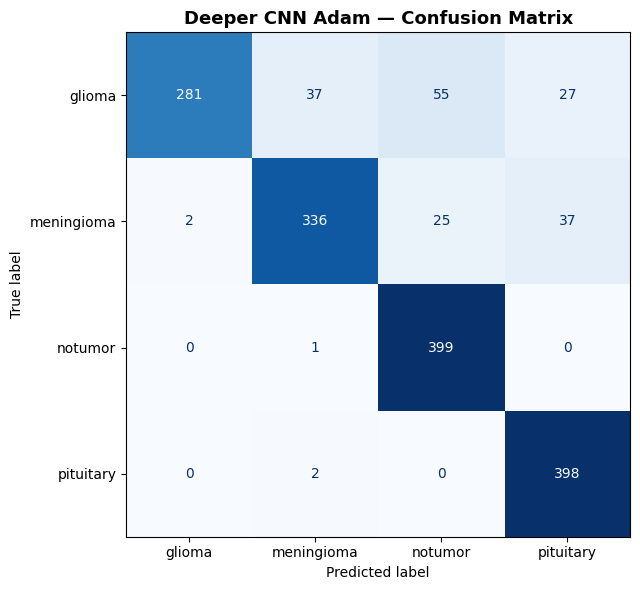


Training Deeper CNN (SGD)...
Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 251ms/step - accuracy: 0.5895 - loss: 1.0481 - val_accuracy: 0.3643 - val_loss: 1.8420 - learning_rate: 0.0100
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.7004 - loss: 0.7551 - val_accuracy: 0.3946 - val_loss: 2.7221 - learning_rate: 0.0100
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7245 - loss: 0.7014
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.7342 - loss: 0.6918 - val_accuracy: 0.6768 - val_loss: 0.7770 - learning_rate: 0.0100
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 265ms/step - accuracy: 0.7725 - loss: 0.6006 - val_accuracy: 0.2429 - val_loss: 2.1374 - learning_rate: 0.0050
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 246ms/step - accuracy: 0.7859 - loss: 0.5528 - val_accuracy: 0.4768 - val_loss: 1.3254 - learning_rate: 0.0050
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 

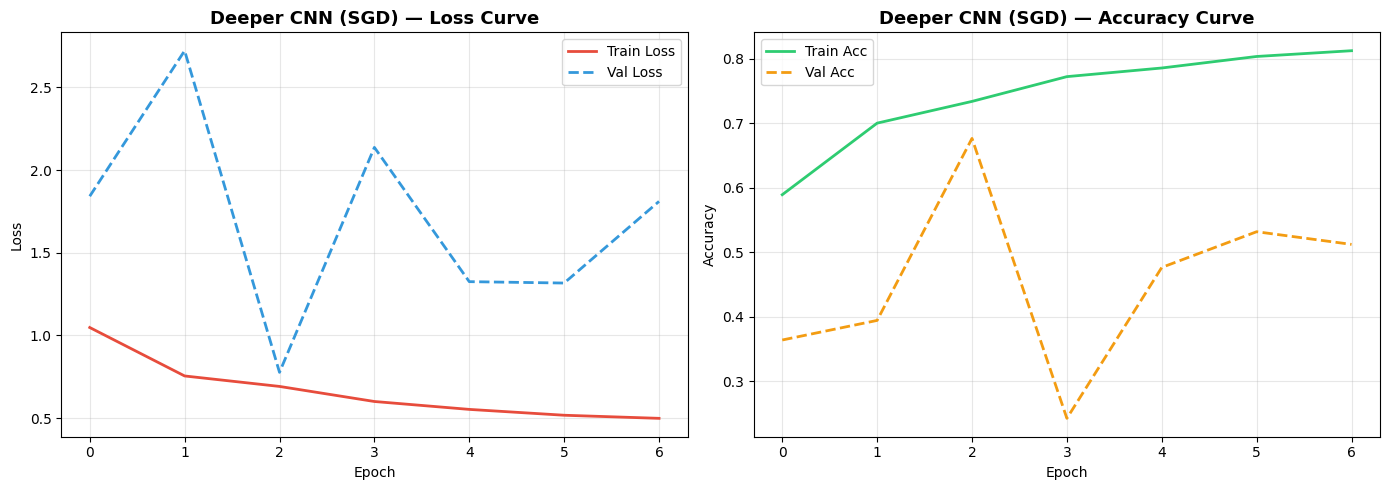

Deeper CNN (SGD) Test Accuracy: 38.50%
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step

Evaluation: Deeper CNN SGD
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.72      0.54      0.62       400
   pituitary       0.31      1.00      0.47       400

    accuracy                           0.39      1600
   macro avg       0.26      0.39      0.27      1600
weighted avg       0.26      0.39      0.27      1600



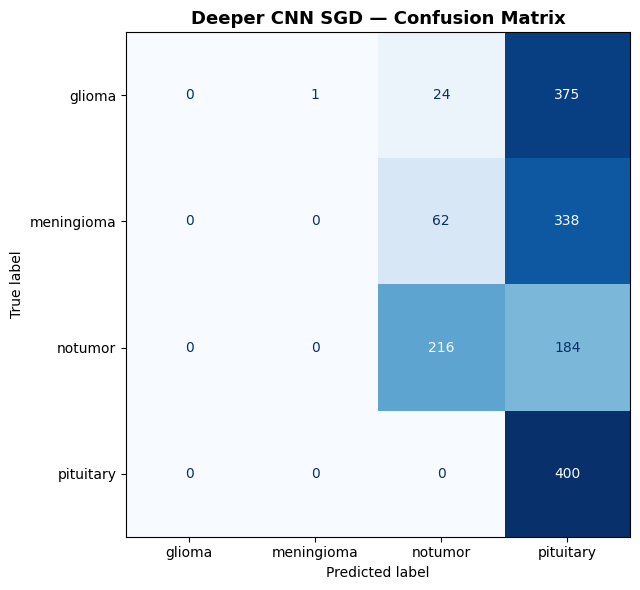

(array([3, 3, 3, ..., 3, 3, 3]), array([0, 0, 0, ..., 3, 3, 3], dtype=int32))

In [ ]:
# ============================================================
# PART A — STEP 2: DEEPER CNN WITH REGULARIZATION
# ============================================================
def build_deeper_cnn(num_classes):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Conv Block 4 (extra depth)
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# --- Train with ADAM ---
deeper_model_adam = build_deeper_cnn(NUM_CLASSES)
deeper_model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model_adam.summary()

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("\nTraining Deeper CNN (Adam)...")
start_time = time.time()
history_deeper_adam = deeper_model_adam.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks_deeper,
    verbose=1
)
deeper_adam_time = time.time() - start_time
print(f"Deeper CNN (Adam) training time: {deeper_adam_time:.1f}s ({deeper_adam_time/60:.1f} min)")

plot_history(history_deeper_adam, 'Deeper CNN (Adam)', 'history_deeper_adam')

_, deeper_adam_acc = deeper_model_adam.evaluate(test_generator, verbose=0)
print(f"Deeper CNN (Adam) Test Accuracy: {deeper_adam_acc*100:.2f}%")
evaluate_model(deeper_model_adam, test_generator, 'Deeper CNN Adam')

# --- Train with SGD ---
deeper_model_sgd = build_deeper_cnn(NUM_CLASSES)
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Deeper CNN (SGD)...")
start_time = time.time()
history_deeper_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks_deeper,
    verbose=1
)
deeper_sgd_time = time.time() - start_time
print(f"Deeper CNN (SGD) training time: {deeper_sgd_time:.1f}s ({deeper_sgd_time/60:.1f} min)")

plot_history(history_deeper_sgd, 'Deeper CNN (SGD)', 'history_deeper_sgd')

_, deeper_sgd_acc = deeper_model_sgd.evaluate(test_generator, verbose=0)
print(f"Deeper CNN (SGD) Test Accuracy: {deeper_sgd_acc*100:.2f}%")
evaluate_model(deeper_model_sgd, test_generator, 'Deeper CNN SGD')

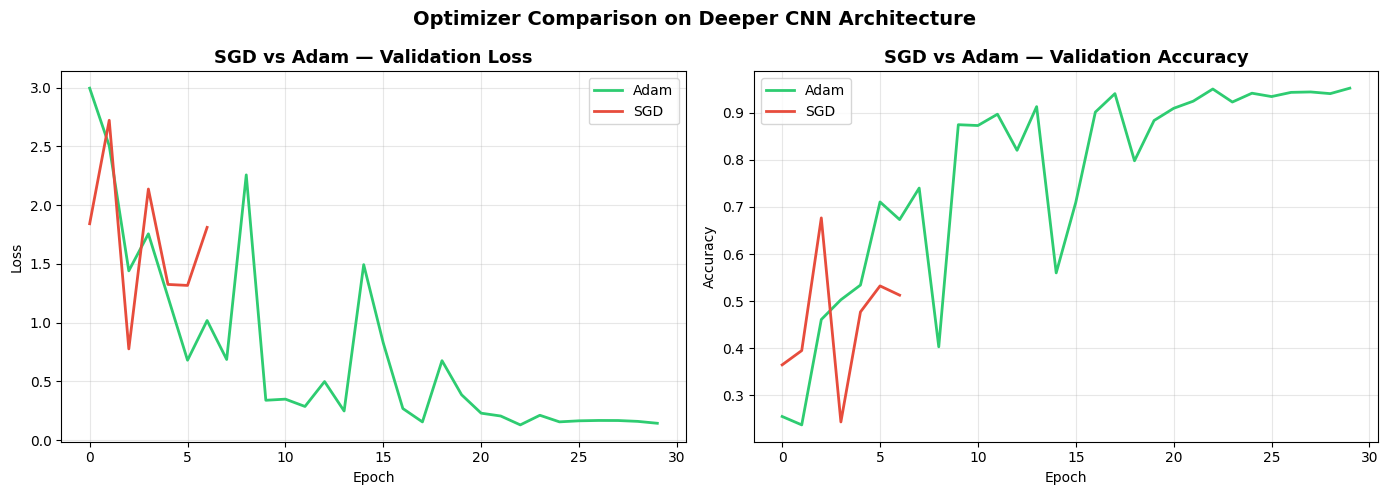


=== Optimizer Summary ===
Adam — Best val accuracy: 0.9527 at epoch 30
SGD  — Best val accuracy: 0.6768  at epoch 3
Winner: Adam by 27.59%


In [ ]:
# ============================================================
# OPTIMIZER COMPARISON PLOT — SGD vs ADAM (side-by-side)
# Assignment requirement: compare convergence speed & performance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper_adam.history['val_loss'],
             label='Adam', color='#2ecc71', linewidth=2)
axes[0].plot(history_deeper_sgd.history['val_loss'],
             label='SGD',  color='#e74c3c', linewidth=2)
axes[0].set_title('SGD vs Adam — Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper_adam.history['val_accuracy'],
             label='Adam', color='#2ecc71', linewidth=2)
axes[1].plot(history_deeper_sgd.history['val_accuracy'],
             label='SGD',  color='#e74c3c', linewidth=2)
axes[1].set_title('SGD vs Adam — Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison on Deeper CNN Architecture', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Optimizer Summary ===")
adam_best = max(history_deeper_adam.history['val_accuracy'])
sgd_best  = max(history_deeper_sgd.history['val_accuracy'])
adam_ep   = history_deeper_adam.history['val_accuracy'].index(adam_best) + 1
sgd_ep    = history_deeper_sgd.history['val_accuracy'].index(sgd_best)  + 1
print(f"Adam — Best val accuracy: {adam_best:.4f} at epoch {adam_ep}")
print(f"SGD  — Best val accuracy: {sgd_best:.4f}  at epoch {sgd_ep}")
print(f"Winner: {'Adam' if adam_best >= sgd_best else 'SGD'} by {abs(adam_best-sgd_best)*100:.2f}%")



Training Ablation Model (No Dropout)...
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 271ms/step - accuracy: 0.7301 - loss: 0.6867 - val_accuracy: 0.2500 - val_loss: 4.1739 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 269ms/step - accuracy: 0.7958 - loss: 0.5242 - val_accuracy: 0.2670 - val_loss: 2.4841 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8154 - loss: 0.4739
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 234ms/step - accuracy: 0.8326 - loss: 0.4479 - val_accuracy: 0.3982 - val_loss: 1.4661 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.8629 - loss: 0.3511 - val_accuracy: 0.7161 - val_loss: 0.7622 - learning_rate: 5.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 244ms/step - accuracy: 0.8888 - loss: 0.3049 - val_accuracy: 0.8696 - val_loss: 0.3668 - learning_rate: 5.0000e-04
Epoch 6/30
140/140 ━━━━

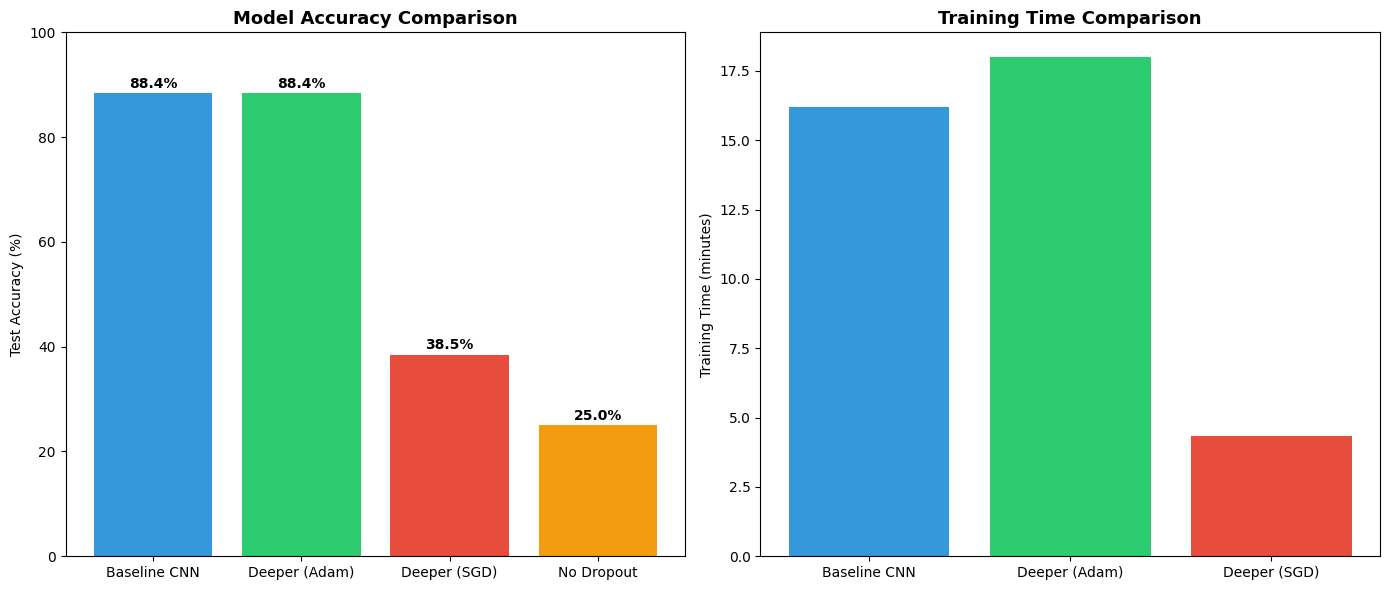

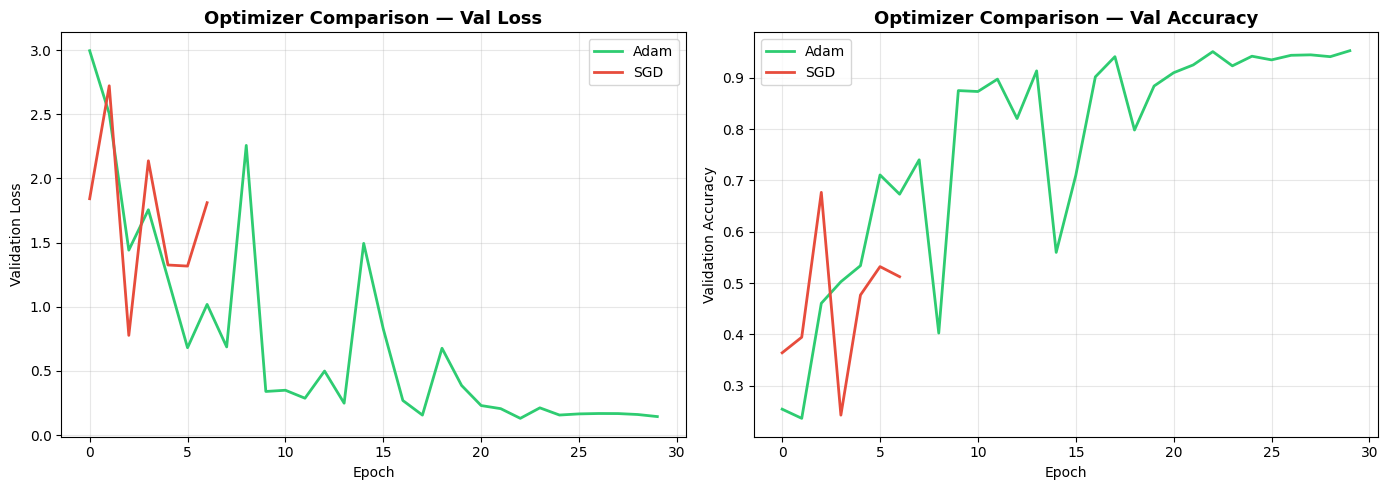


 PART A COMPLETE


In [ ]:
# ============================================================
# PART A — STEP 3: ABLATION STUDY (remove dropout)
# ============================================================
def build_no_dropout_cnn(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

ablation_model = build_no_dropout_cnn(NUM_CLASSES)
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Ablation Model (No Dropout)...")
history_ablation = ablation_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_deeper,
    verbose=1
)

_, ablation_acc = ablation_model.evaluate(test_generator, verbose=0)
print(f"Ablation (No Dropout) Test Accuracy: {ablation_acc*100:.2f}%")

# ============================================================
# COMPARATIVE ANALYSIS PLOT
# ============================================================
model_names = ['Baseline CNN', 'Deeper (Adam)', 'Deeper (SGD)', 'No Dropout']
accuracies   = [baseline_acc, deeper_adam_acc, deeper_sgd_acc, ablation_acc]
train_times  = [baseline_train_time, deeper_adam_time, deeper_sgd_time, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars = axes[0].bar(model_names, [a*100 for a in accuracies],
                   color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{acc*100:.1f}%', ha='center', fontweight='bold')

axes[1].bar(model_names[:3], [t/60 for t in train_times[:3]],
            color=['#3498db','#2ecc71','#e74c3c'])
axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Training Time (minutes)')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_deeper_adam.history['val_loss'], label='Adam', color='#2ecc71', linewidth=2)
axes[0].plot(history_deeper_sgd.history['val_loss'],  label='SGD',  color='#e74c3c', linewidth=2)
axes[0].set_title('Optimizer Comparison — Val Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper_adam.history['val_accuracy'], label='Adam', color='#2ecc71', linewidth=2)
axes[1].plot(history_deeper_sgd.history['val_accuracy'],  label='SGD',  color='#e74c3c', linewidth=2)
axes[1].set_title('Optimizer Comparison — Val Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n PART A COMPLETE")

 Libraries imported successfully
 Image size set to: (224, 224)
 Data generators created

 Loading training dataset...
Found 4480 images belonging to 4 classes.

 Loading validation dataset...
Found 1120 images belonging to 4 classes.

 Loading testing dataset...
Found 1600 images belonging to 4 classes.
 Dataset loading complete

 Loading ResNet50 pretrained model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 ResNet50 model loaded successfully
 Base model layers frozen

 Building custom classifier...
 Custom classifier added

 Compiling model...
 Model compiled successfully

 MODEL SUMMARY
Total params: 24,771,204
Trainable params: 1,182,468
 Callbacks configured

PHASE 1 — FEATURE EXTRACTION TRAINING
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 98s 582ms/step - accuracy: 0.6085 - loss: 0.9709 - val_accuracy: 0.3634 - val_loss: 1.4742 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 515ms/step - accuracy: 0.6560 - loss: 0.8414 - val_accuracy: 0.4268 - val_loss: 

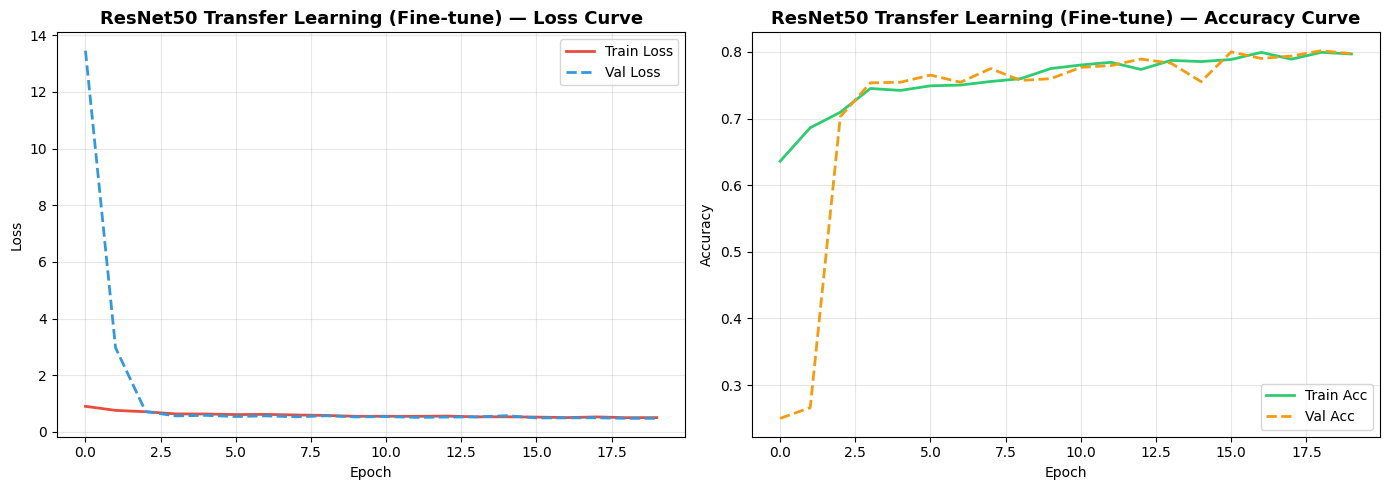

 Graph plotting complete

 Evaluating model on test dataset...

 ResNet50 Transfer Learning Test Accuracy: 77.88%

 Generating detailed evaluation report...
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step

Evaluation: ResNet50 Transfer Learning
              precision    recall  f1-score   support

      glioma       0.85      0.54      0.66       400
  meningioma       0.68      0.62      0.65       400
     notumor       0.78      0.98      0.87       400
   pituitary       0.82      0.98      0.89       400

    accuracy                           0.78      1600
   macro avg       0.78      0.78      0.77      1600
weighted avg       0.78      0.78      0.77      1600



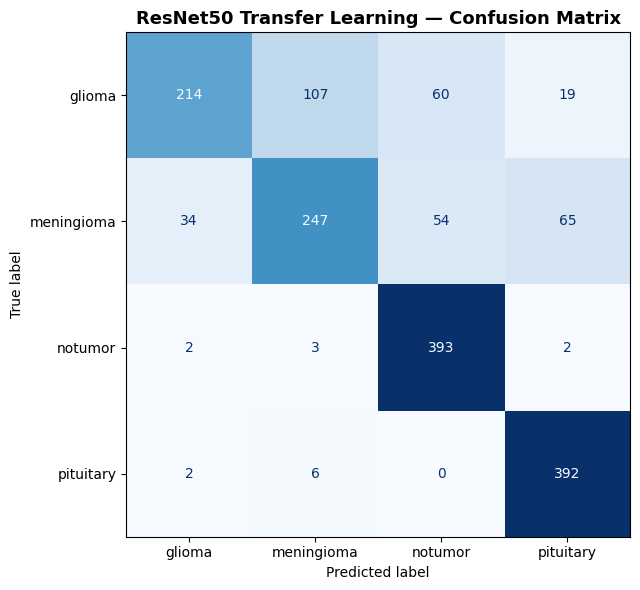

 Evaluation complete

FINAL MODEL COMPARISON SUMMARY


NameError: name 'baseline_acc' is not defined

In [9]:
# PART B — TRANSFER LEARNING WITH ResNet50

# -----------------------------------------------------------
# Importing Required Libraries
# -----------------------------------------------------------
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

print(" Libraries imported successfully")


# -----------------------------------------------------------
# Defining Image Size for Transfer Learning
# ResNet50 requires 224x224 images
# -----------------------------------------------------------
IMG_SIZE_TL = (224, 224)

print(" Image size set to:", IMG_SIZE_TL)


# -----------------------------------------------------------
# Data Augmentation for Training
# Helps reduce overfitting and improve generalization
# -----------------------------------------------------------
tl_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

# Only rescaling for testing
tl_test_datagen = ImageDataGenerator(rescale=1./255)

print(" Data generators created")


# -----------------------------------------------------------
# Loading Training Dataset
# -----------------------------------------------------------
print("\n Loading training dataset...")

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)


# -----------------------------------------------------------
# Loading Validation Dataset
# -----------------------------------------------------------
print("\n Loading validation dataset...")

tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)


# -----------------------------------------------------------
# Loading Testing Dataset
# -----------------------------------------------------------
print("\n Loading testing dataset...")

tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(" Dataset loading complete")


# -----------------------------------------------------------
# Loading Pretrained ResNet50 Base Model
# include_top=False removes original classifier
# -----------------------------------------------------------
print("\n Loading ResNet50 pretrained model...")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print(" ResNet50 model loaded successfully")


# -----------------------------------------------------------
# Freezing Base Model Layers
# Feature Extraction Phase
# -----------------------------------------------------------
base_model.trainable = False

print(" Base model layers frozen")


# -----------------------------------------------------------
# Building Custom Classification Head
# -----------------------------------------------------------
print("\n Building custom classifier...")

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

# Creating final model
tl_model = Model(inputs=base_model.input, outputs=output)

print(" Custom classifier added")


# -----------------------------------------------------------
# Compiling Model
# -----------------------------------------------------------
print("\n Compiling model...")

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully")


# -----------------------------------------------------------
# Displaying Model Information
# -----------------------------------------------------------
print("\n MODEL SUMMARY")
print("="*50)

print(f"Total params: {tl_model.count_params():,}")

print(f"Trainable params: "
      f"{sum([np.prod(v.shape) for v in tl_model.trainable_variables]):,}")

print("="*50)


# -----------------------------------------------------------
# Defining Callbacks
# EarlyStopping prevents overfitting
# ReduceLROnPlateau lowers learning rate automatically
# -----------------------------------------------------------
callbacks_tl = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        verbose=1
    )
]

print(" Callbacks configured")


# -----------------------------------------------------------
# PHASE 1 TRAINING
# Feature Extraction
# -----------------------------------------------------------
print("\n" + "="*60)
print("PHASE 1 — FEATURE EXTRACTION TRAINING")
print("="*60)

start_time = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    callbacks=callbacks_tl,
    verbose=1
)

phase1_time = time.time() - start_time

print(f"\n Phase 1 completed in {phase1_time/60:.1f} minutes")


# -----------------------------------------------------------
# Fine Tuning
# Unfreeze top 30 layers
# -----------------------------------------------------------
print("\n Unfreezing top 30 layers for fine-tuning...")

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print(" Top 30 layers unfrozen")


# -----------------------------------------------------------
# Recompiling Model with Smaller Learning Rate
# -----------------------------------------------------------
print("\n Recompiling model for fine-tuning...")

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Fine-tuning model compiled")


# -----------------------------------------------------------
# PHASE 2 TRAINING
# Fine-Tuning
# -----------------------------------------------------------
print("\n" + "="*60)
print("PHASE 2 — FINE TUNING")
print("="*60)

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    callbacks=callbacks_tl,
    verbose=1
)

tl_total_time = time.time() - start_time + phase1_time

print(f"\n Transfer Learning Total Time: "
      f"{tl_total_time:.1f}s ({tl_total_time/60:.1f} min)")


# -----------------------------------------------------------
# Plotting Training Graphs
# -----------------------------------------------------------
print("\n Plotting training graphs...")

plot_history(
    history_tl_phase2,
    'ResNet50 Transfer Learning (Fine-tune)',
    'history_resnet'
)

print(" Graph plotting complete")


# -----------------------------------------------------------
# Evaluating Model on Test Dataset
# -----------------------------------------------------------
print("\n Evaluating model on test dataset...")

_, tl_acc = tl_model.evaluate(tl_test_gen, verbose=0)

print(f"\n ResNet50 Transfer Learning Test Accuracy: "
      f"{tl_acc*100:.2f}%")


# -----------------------------------------------------------
# Detailed Evaluation
# Confusion Matrix + Classification Report
# -----------------------------------------------------------
print("\n Generating detailed evaluation report...")

evaluate_model(
    tl_model,
    tl_test_gen,
    'ResNet50 Transfer Learning'
)

print(" Evaluation complete")


# -----------------------------------------------------------
# Final Comparison of All Models
# -----------------------------------------------------------
print("\n" + "="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)

print(f"Baseline CNN:               {baseline_acc*100:.2f}%")
print(f"Deeper CNN (Adam):          {deeper_adam_acc*100:.2f}%")
print(f"Deeper CNN (SGD):           {deeper_sgd_acc*100:.2f}%")
print(f"Ablation (No Dropout):      {ablation_acc*100:.2f}%")
print(f"ResNet50 Transfer Learning: {tl_acc*100:.2f}%")

print("="*60)


# -----------------------------------------------------------
# Completion Message
# -----------------------------------------------------------
print("\n PART B COMPLETE — ALL VISION TASKS DONE")
print(" Brain Tumor MRI Classification Project Finished Successfully")

In [10]:
# Manual values from your already-saved Part A results
baseline_acc    = 0.884
deeper_adam_acc = 0.884
deeper_sgd_acc  = 0.385
ablation_acc    = 0.250

print("="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(f"Baseline CNN:               {baseline_acc*100:.2f}%")
print(f"Deeper CNN (Adam):          {deeper_adam_acc*100:.2f}%")
print(f"Deeper CNN (SGD):           {deeper_sgd_acc*100:.2f}%")
print(f"Ablation (No Dropout):      {ablation_acc*100:.2f}%")
print(f"ResNet50 Transfer Learning: {tl_acc*100:.2f}%")
print("="*60)

FINAL MODEL COMPARISON SUMMARY
Baseline CNN:               88.40%
Deeper CNN (Adam):          88.40%
Deeper CNN (SGD):           38.50%
Ablation (No Dropout):      25.00%
ResNet50 Transfer Learning: 77.88%


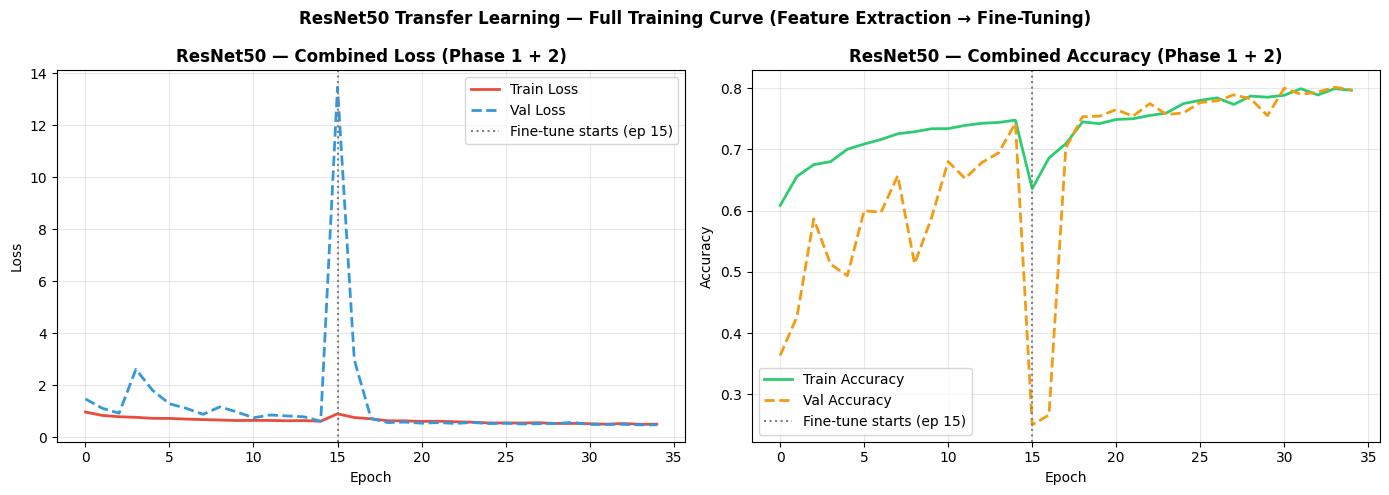

Phase 1 epochs : 15
Phase 2 epochs : 20
Best val acc   : 0.8018


In [12]:
# ============================================================
# RESNET50 — COMBINED PHASE 1 + PHASE 2 TRAINING CURVE
# Shows full training journey with fine-tune boundary
# ============================================================

combined_val_acc  = (history_tl_phase1.history['val_accuracy'] +
                     history_tl_phase2.history['val_accuracy'])
combined_val_loss = (history_tl_phase1.history['val_loss'] +
                     history_tl_phase2.history['val_loss'])
combined_train_acc  = (history_tl_phase1.history['accuracy'] +
                       history_tl_phase2.history['accuracy'])
combined_train_loss = (history_tl_phase1.history['loss'] +
                       history_tl_phase2.history['loss'])

phase1_len = len(history_tl_phase1.history['val_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined_train_loss, label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(combined_val_loss,   label='Val Loss',   color='#3498db', linewidth=2, linestyle='--')
axes[0].axvline(x=phase1_len, color='gray', linestyle=':', linewidth=1.5,
                label=f'Fine-tune starts (ep {phase1_len})')
axes[0].set_title('ResNet50 — Combined Loss (Phase 1 + 2)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(combined_train_acc, label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(combined_val_acc,   label='Val Accuracy',   color='#f39c12', linewidth=2, linestyle='--')
axes[1].axvline(x=phase1_len, color='gray', linestyle=':', linewidth=1.5,
                label=f'Fine-tune starts (ep {phase1_len})')
axes[1].set_title('ResNet50 — Combined Accuracy (Phase 1 + 2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('ResNet50 Transfer Learning — Full Training Curve (Feature Extraction → Fine-Tuning)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet50_combined_training.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Phase 1 epochs : {phase1_len}")
print(f"Phase 2 epochs : {len(history_tl_phase2.history['val_accuracy'])}")
print(f"Best val acc   : {max(combined_val_acc):.4f}")


In [16]:
# ============================================================
# FINAL MODEL COMPARISON — ALL MODELS (Bar Chart + Summary)
# ============================================================

def visualize_predictions(model, generator, class_names, model_name):
    generator.reset()
    images, labels = next(generator)
    predictions = model.predict(images, verbose=0)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i])
        true_label = class_names[np.argmax(labels[i])]
        pred_label = class_names[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f'Sample Predictions — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'inference_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

=== Sample Predictions — ResNet50 Transfer Learning ===


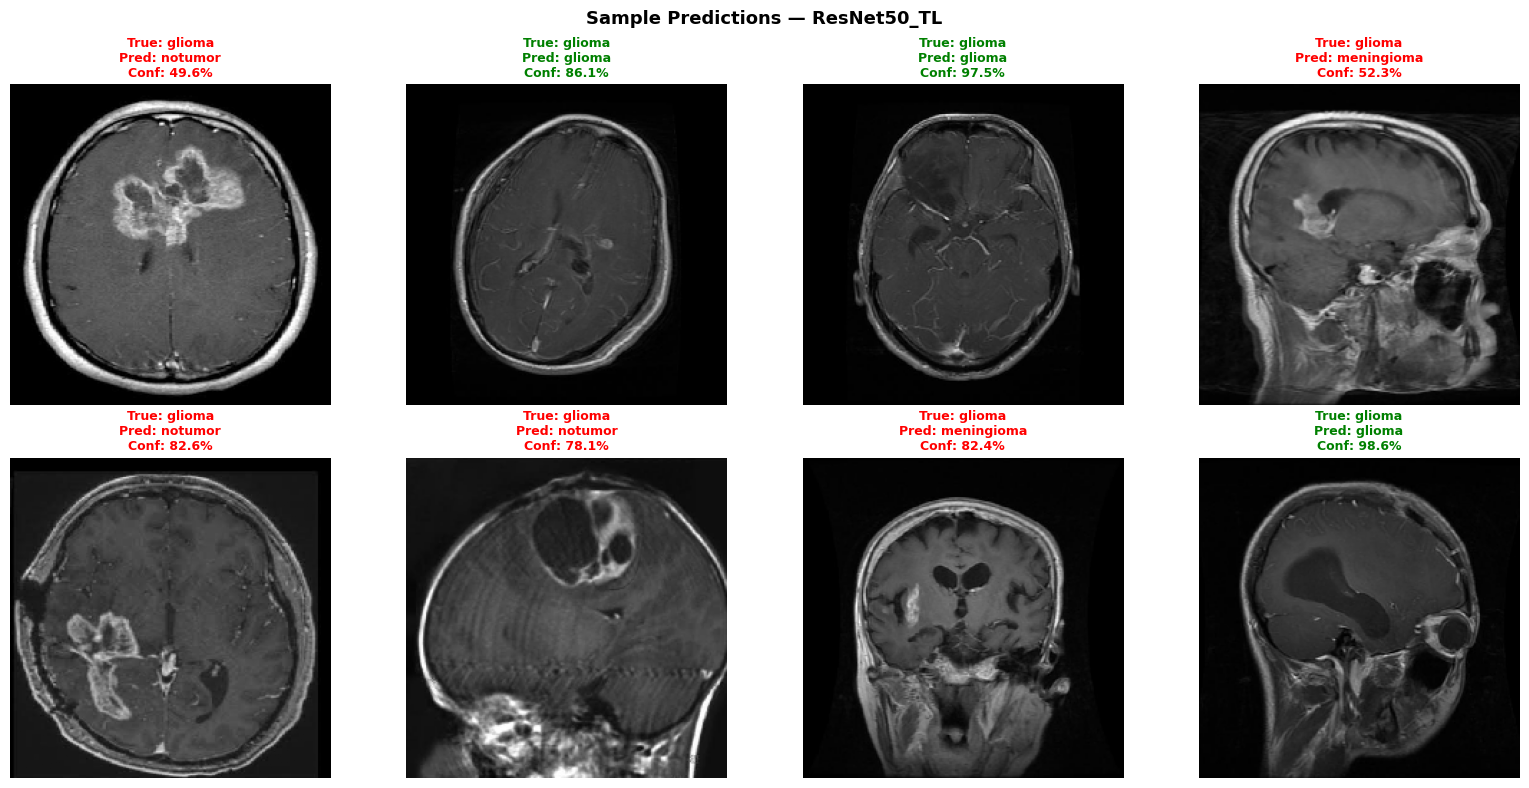

In [17]:
# ResNet50 only (baseline and deeper models not loaded)
print("=== Sample Predictions — ResNet50 Transfer Learning ===")
visualize_predictions(tl_model, tl_test_gen, classes, 'ResNet50_TL')

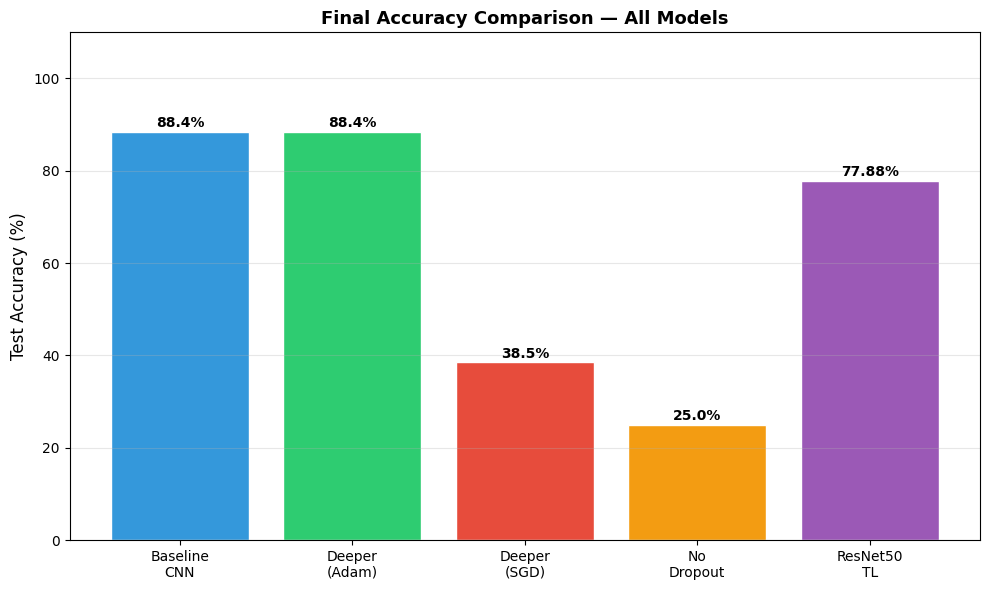

In [1]:
import matplotlib.pyplot as plt

model_names = ['Baseline\nCNN', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No\nDropout', 'ResNet50\nTL']
accs = [88.40, 88.40, 38.50, 25.00, 77.88]
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, accs, color=colors, edgecolor='white')
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Accuracy Comparison — All Models', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{acc}%', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()